# 2-Category Simplex: Are the transforms still different?

No, they only differ by rescaling and we will demonstrate that empirically and mathematically.

Here the simplex has only **two categories**, so the unconstrained space has only **one latent dimension**.

In this setting, PyMC's default anchored simplex transform and the NumPyro / stick-breaking transform do **not** define different variational families on the simplex. They differ only by a linear rescaling of the latent Gaussian.


## Why the Families Coincide in 1 Latent Dimension

Let `z` denote PyMC's default latent coordinate for a 2-category simplex and let `u` denote the stick-breaking latent coordinate.

For PyMC's default anchored transform with `K = 2`, the logits are `[z, -z]`, so

$$
\theta_1
= \frac{e^z}{e^z + e^{-z}}
= \operatorname{sigmoid}(2z),
\qquad
\theta_2 = 1 - \theta_1.
$$

For the stick-breaking transform with `K = 2`, there is only one break and no centering offset, so

$$
\theta_1 = \operatorname{sigmoid}(u),
\qquad
\theta_2 = 1 - \theta_1.
$$

Therefore the two transforms agree exactly after the change of variables

$$
u = 2z.
$$

So if

$$
z \sim \mathcal{N}(\mu, \sigma^2),
$$

then

$$
u = 2z \sim \mathcal{N}(2\mu, (2\sigma)^2),
$$

and both transforms generate the **same** family of simplex distributions, hence there is no transform mismatch in the 2-category / 1-latent-dimensional case.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import pytensor

from scipy.special import expit
from scipy.stats import gaussian_kde

from modulars.distributions import gen_multinomial_data_shared, lda_posterior_shared_theta
from modulars.pymc_rr_test import StickBreakingSimplexTransform, run_pymc_VI
from modulars.utils import (
    anchored_softmax_simplex_forward,
    stickbreaking_simplex_forward,
    simplex_moments_from_cov,
)

if os.environ.get("SIMPLEVI_PYTENSOR_CXX"):
    pytensor.config.cxx = os.environ["SIMPLEVI_PYTENSOR_CXX"]
np.set_printoptions(suppress=True, precision=4)


In [27]:
def anchored_theta1(z):
    z = np.asarray(z, dtype=float)
    return expit(2.0 * z)


def stick_theta1(u):
    u = np.asarray(u, dtype=float)
    return expit(u)


def print_rows_table(rows, float_digits=4):
    if len(rows) == 0:
        print("[]")
        return

    columns = list(rows[0].keys())
    formatted_rows = []
    for row in rows:
        formatted = []
        for col in columns:
            value = row[col]
            if isinstance(value, float):
                formatted.append(f"{value:.{float_digits}f}")
            else:
                formatted.append(str(value))
        formatted_rows.append(formatted)

    widths = []
    for col_idx, col in enumerate(columns):
        widths.append(max(len(col), max(len(row[col_idx]) for row in formatted_rows)))

    header = " | ".join(col.ljust(widths[i]) for i, col in enumerate(columns))
    divider = "-+-".join("-" * widths[i] for i in range(len(columns)))
    print(header)
    print(divider)
    for row in formatted_rows:
        print(" | ".join(row[i].ljust(widths[i]) for i in range(len(columns))))


def sample_theta_equivalence(mu=0.35, sigma=0.8, n_draws=5_000_000, seed=4):
    # Sample z ~ N(mu, sigma^2) and compute:
    # theta1 = anchored_softmax_simplex_forward(z)
    #  and theta2 = stickbreaking_simplex_forward(2z)
    # and then compare the means and stds of theta1 and theta2, as well as the max and mean absolute difference between them.
    rng = np.random.default_rng(seed)
    z = rng.normal(loc=mu, scale=sigma, size=n_draws)
    u = rng.normal(loc=2*mu, scale=2*sigma, size=n_draws)

    theta1_anchored = anchored_theta1(z)
    theta1_stick_rescaled = stick_theta1(u)
    theta1_stick_same_params = stick_theta1(
        rng.normal(loc=mu, scale=sigma, size=n_draws)
    )

    rows = [
        {
            "family": "Anchored from z ~ N(mu, sigma^2)",
            "mean": float(theta1_anchored.mean()),
            "std": float(theta1_anchored.std()),
        },
        {
            "family": "Stick-breaking from u = 2z",
            "mean": float(theta1_stick_rescaled.mean()),
            "std": float(theta1_stick_rescaled.std()),
        },
        {
            "family": "Stick-breaking from u ~ N(mu, sigma^2)",
            "mean": float(theta1_stick_same_params.mean()),
            "std": float(theta1_stick_same_params.std()),
        },
    ]
    print_rows_table(rows, float_digits=6)
                                           


## Direct Numerical Check of the Rescaling Identity

The key comparison is comparing anchored transform to a stick breaking transform of a scaled normal

- `anchored(z)` with `z ~ Normal(mu, sigma^2)`
- `stick-breaking(u)` with `u = 2z ~ Normal(2mu, (2sigma)^2)`



In [28]:
sample_theta_equivalence(mu=0.35, sigma=0.8, n_draws=20_000_000, seed=4)


family                                 | mean     | std     
---------------------------------------+----------+---------
Anchored from z ~ N(mu, sigma^2)       | 0.617974 | 0.269895
Stick-breaking from u = 2z             | 0.617910 | 0.269888
Stick-breaking from u ~ N(mu, sigma^2) | 0.576158 | 0.172607


We can also verify the same identity using the helper functions that we have written for the dirichlet notebooks.


In [18]:
mu = np.array([0.35])
sigma = np.array([0.8])
rng = np.random.default_rng(9)
z = rng.normal(loc=mu, scale=sigma, size=(120_000, 1))
u = 2.0 * z

theta_anchor = anchored_softmax_simplex_forward(z, n_cats=2)
theta_stick = stickbreaking_simplex_forward(u, n_cats=2)

print("max absolute difference over both simplex coordinates:")
print(np.max(np.abs(theta_anchor - theta_stick)))
print()
print("anchored simplex mean:", theta_anchor.mean(axis=0))
print("stick-breaking simplex mean after rescaling:", theta_stick.mean(axis=0))
print()
print("anchored simplex std:", theta_anchor.std(axis=0))
print("stick-breaking simplex std after rescaling:", theta_stick.std(axis=0))


max absolute difference over both simplex coordinates:
2.220446049250313e-16

anchored simplex mean: [0.6182 0.3818]
stick-breaking simplex mean after rescaling: [0.6182 0.3818]

anchored simplex std: [0.2702 0.2702]
stick-breaking simplex std after rescaling: [0.2702 0.2702]


## A Small PyMC Example in 2-Category Simplex Space

Now we demonstrate the same idea with PyMC on a 2-category Dirichlet-multinomial model.

We fit the same model twice:

- once with PyMC's default anchored simplex transform
- once with the custom stick-breaking simplex transform

Since there is only one latent dimension, the fitted simplex families should agree after the latent rescaling

- `u = 2z`
- `mu_stick = 2 * mu_default`
- `sigma_stick = 2 * sigma_default`


In [6]:
theta_like = np.array([0.72, 0.28], dtype=np.float32)
alpha_prior = np.array([1.0, 1.0], dtype=np.float32)
N = 10
total_count = 50
n_iters = 50_000
n_samples_transport = 10_000
seed = 8

n_vec = np.full(N, total_count, dtype=int)
obs_counts = gen_multinomial_data_shared(theta_like, N, total_count, SEED=seed)
true_post = lda_posterior_shared_theta(observations=obs_counts, alpha=alpha_prior)

print("Observed aggregated counts:", obs_counts.sum(axis=0))
print("Conjugate posterior alpha:", true_post["alpha_post"])
print("Conjugate posterior mean:", true_post["mean_post"])
print("Conjugate posterior std:", true_post["std_post"])


Observed aggregated counts: [357 143]
Conjugate posterior alpha: [358. 144.]
Conjugate posterior mean: [0.7131 0.2869]
Conjugate posterior std: [0.0202 0.0202]


In [7]:
def build_pymc_dirichlet_model(simplex_transform="default"):
    with pm.Model() as model:
        if simplex_transform == "default":
            theta = pm.Dirichlet("theta", a=alpha_prior)
        elif simplex_transform == "stickbreaking":
            theta = pm.Dirichlet(
                "theta",
                a=alpha_prior,
                default_transform=StickBreakingSimplexTransform(),
            )
        else:
            raise ValueError("simplex_transform must be 'default' or 'stickbreaking'")
        pm.Multinomial("y", n=n_vec, p=theta, observed=np.array(obs_counts))
    return model


def run_pymc_once(simplex_transform, seed, n_iters=10_000, n_mc_samples=100):
    with build_pymc_dirichlet_model(simplex_transform=simplex_transform) as model:
        loc_traj, cov_traj = run_pymc_VI(
            model,
            n_mc_samples=n_mc_samples,
            n_iters=n_iters,
            optimizer="default",
            seed=seed,
            SINGLE_DIM=False,
        )
    return np.asarray(loc_traj), np.asarray(cov_traj)


In [8]:
run_kwargs = {'seed': 11, 'n_iters': n_iters, 'n_mc_samples': 100}
default_loc_traj, default_cov_traj = run_pymc_once("default", **run_kwargs)
stick_loc_traj, stick_cov_traj = run_pymc_once("stickbreaking", **run_kwargs)

default_final_loc = default_loc_traj[-1].reshape(-1)
default_final_cov = np.asarray(default_cov_traj[-1], dtype=float).reshape(1, 1)
default_final_std = float(np.sqrt(default_final_cov[0, 0]))

stick_final_loc = stick_loc_traj[-1].reshape(-1)
stick_final_cov = np.asarray(stick_cov_traj[-1], dtype=float).reshape(1, 1)
stick_final_std = float(np.sqrt(stick_final_cov[0, 0]))

implied_stick_loc = 2.0 * default_final_loc
implied_stick_cov = 4.0 * default_final_cov
implied_stick_std = float(np.sqrt(implied_stick_cov[0, 0]))

summary_rows = [
    {
        "fit": "PyMC default latent z",
        "loc": float(default_final_loc[0]),
        "std": default_final_std,
    },
    {
        "fit": "Actual stick-breaking latent u",
        "loc": float(stick_final_loc[0]),
        "std": stick_final_std,
    },
    {
        "fit": "stick-breaking latent u=2z in terms of z",
        "loc": float(implied_stick_loc[0]),
        "std": implied_stick_std,
    },
]
print_rows_table(summary_rows)


Finished [100%]: Average Loss = 29.885
Finished [100%]: Average Loss = 29.885


fit                                      | loc    | std   
-----------------------------------------+--------+-------
PyMC default latent z                    | 0.4566 | 0.0492
Actual stick-breaking latent u           | 0.9136 | 0.0985
stick-breaking latent u=2z in terms of z | 0.9132 | 0.0985


In [9]:
simplex_kwargs = {'n_cats': 2, 'seed': 1, 'n_samples': n_samples_transport}
default_means, default_stds = simplex_moments_from_cov(
    default_loc_traj, default_cov_traj,
    forward_fn=anchored_softmax_simplex_forward,
    **simplex_kwargs
)

stick_means, stick_stds = simplex_moments_from_cov(
    stick_loc_traj, stick_cov_traj,
    forward_fn=stickbreaking_simplex_forward,
    **simplex_kwargs
)

implied_stick_means, implied_stick_stds = simplex_moments_from_cov(
    2.0 * default_loc_traj, 4.0 * default_cov_traj,
    forward_fn=stickbreaking_simplex_forward,
    **simplex_kwargs
)



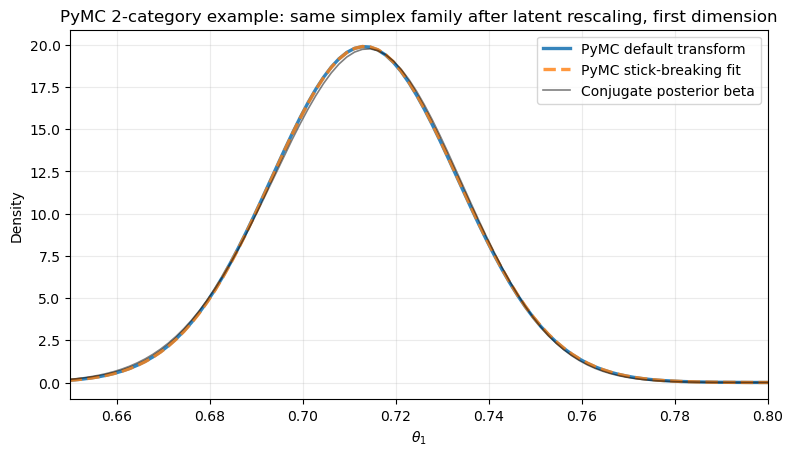

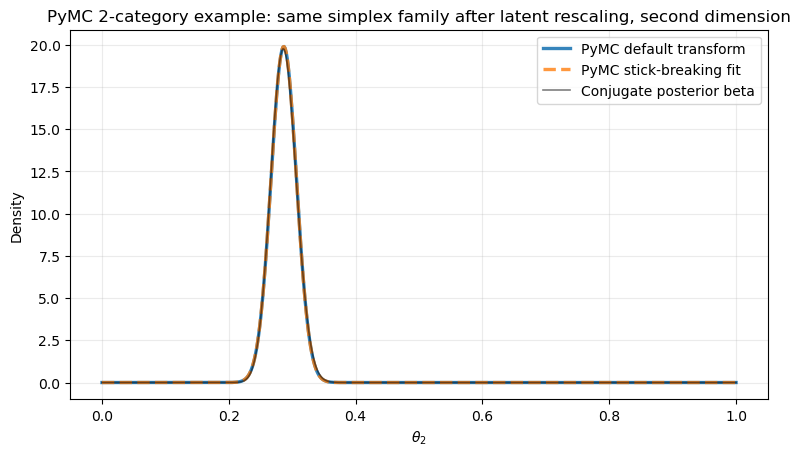

In [15]:
x = np.linspace(1e-4, 1 - 1e-4, 600)
from scipy.stats import norm, beta
# Plot the variational posterior approximations in terms of z and compare
# to the conjugate posterior marginal beta

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(x, norm.pdf(x, loc=default_means[-1][0], scale=default_stds[-1][0]), color="tab:blue", linewidth=2.4, label="PyMC default transform", alpha=0.9)
ax.plot(x, norm.pdf(x, loc=stick_means[-1][0], scale=stick_stds[-1][0]), color="tab:orange", linewidth=2.4, linestyle="--", label="PyMC stick-breaking fit", alpha=0.8)

ax.plot(x, beta.pdf(x, a=true_post["alpha_post"][0], b=true_post["alpha_post"][1]), color="black", linewidth=1.2, alpha=0.5, label="Conjugate posterior beta")
ax.set_title(r"PyMC 2-category example: same simplex family after latent rescaling, first dimension")
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel("Density")
ax.grid(alpha=0.25)
ax.legend(loc="best")
ax.set_xlim(0.65, 0.8)
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(x, norm.pdf(x, loc=default_means[-1][1], scale=default_stds[-1][1]), color="tab:blue", linewidth=2.4, label="PyMC default transform", alpha=0.9)
ax.plot(x, norm.pdf(x, loc=stick_means[-1][1], scale=stick_stds[-1][1]), color="tab:orange", linewidth=2.4, linestyle="--", label="PyMC stick-breaking fit", alpha=0.8)

ax.plot(x, beta.pdf(x, a=true_post["alpha_post"][1], b=true_post["alpha_post"][0]), color="black", linewidth=1.2, alpha=0.5, label="Conjugate posterior beta")
ax.set_title(r"PyMC 2-category example: same simplex family after latent rescaling, second dimension")
ax.set_xlabel(r"$\theta_2$")
ax.set_ylabel("Density")
ax.grid(alpha=0.25)
ax.legend(loc="best")
# ax.set_xlim(0.65, 0.8)
plt.show()
